🟢 DESAFIO 1: Análise de Varejo (RFM)
Vamos usar o famoso dataset Online Retail. Ele contém transações de uma loja online baseada no Reino Unido.

💼 O Problema de Negócio
O Diretor de Marketing quer segmentar a base. Ele não quer tratar todos os clientes iguais. Ele quer saber:

Quem comprou recentemente? (R - Recency)

Quem compra sempre? (F - Frequency)

Quem gasta muito? (M - Monetary)

Base de dados: https://www.kaggle.com/datasets/vijayuv/onlineretail

In [ ]:
#Passo a Passo
## Passo 1: Carregamento de dados
import pandas as pd

tabela = pd.read_csv("OnlineRetail.csv", encoding="latin1")
display(tabela)
display(tabela.info())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

In [ ]:
##Verificação de valores nulos e valores negativos
tabela = tabela.dropna(subset=["CustomerID"])
display(tabela.info())
tabela = tabela[(tabela["Quantity"] > 0) & (tabela["UnitPrice"] > 0)]
display(tabela.info())

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


None

In [8]:
##criação de uma tabela TotalPrice para saber o valor monetario
tabela["TotalPrice"] = tabela["Quantity"] * tabela["UnitPrice"]
#transformando a coluna InvoiceDate no formatado data
tabela["InvoiceDate"] = pd.to_datetime(tabela["InvoiceDate"])
display(tabela.info())

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


None

In [9]:
##Para calcularmos a recência, precisamos de uma data de referencia, como o dataset é de 2011 buscaremos o ultimo 
# dia da compra e fingiremos que "hoje" é o dia seguinte
data_maxima = tabela["InvoiceDate"].max()
print(data_maxima)

2011-12-09 12:50:00


In [16]:
##Definir a data de referência(10-12-2011)
import datetime as dt
data_referencia = tabela["InvoiceDate"].max() + dt.timedelta(days=1)

##Agrupar os dados por CustomerID
rfm = tabela.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (data_referencia - x.max()).days,##Pegou a ultima vez que o cliente foi a loja
    "InvoiceNo": "nunique",##Quantas fezes ele veio ate a loja, nao quantos produtos comprou
    "TotalPrice": "sum"##somou todos os valores
})
#Renomeando as colunas para ficar mais bonito e intuitivo
rfm.rename(columns= {
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
}, inplace=True)
##mostrando os resultados
display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
#Criando Rótulos de 1 a 4
labels_bons = [1, 2, 3, 4]#qaunto maior, melhor
labels_ruins = [4, 3, 2, 1]#quanto maior, pior a nota

rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=labels_ruins)

rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=labels_bons) #criou um rank artificial para facilitar a contagem do apndas devido a grande quantidade de numeros 1

rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4, labels=labels_bons)

rfm["RFM_Group"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

display(rfm.head())

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [18]:
# Filtrando quem tem a pontuação máxima
campeoes = rfm[rfm["RFM_Group"] == "444"]
print(f"Temos {len(campeoes)} clientes campeões!")
display(campeoes.head())

Temos 490 clientes campeões!


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
CustomerID,,,,,,,
12347.0,2,7,4310.00,4,4,4,444
12362.0,3,10,5226.23,4,4,4,444
12388.0,16,6,2780.66,4,4,4,444
12417.0,3,9,3649.10,4,4,4,444
12423.0,1,8,1859.31,4,4,4,444


C:\Users\João Luís\AppData\Local\Temp\ipykernel_18216\2181775404.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem.index, y=contagem.values, palette="viridis")


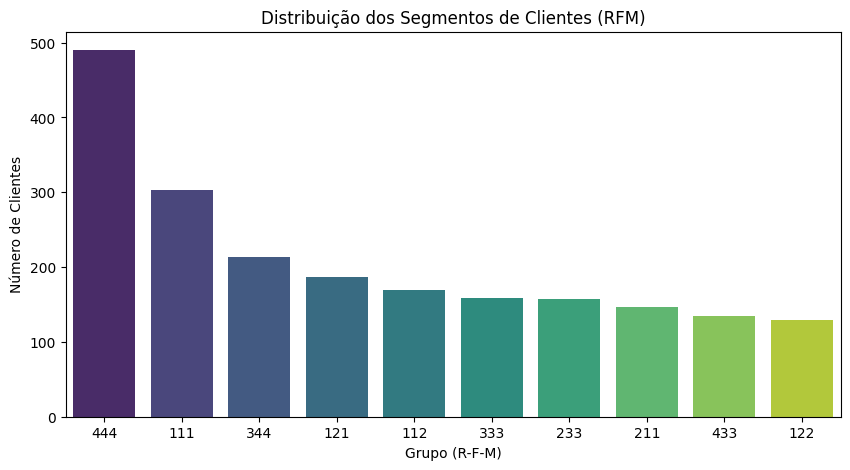

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vamos contar quantos clientes temos em cada grupo
contagem = rfm['RFM_Group'].value_counts().head(10) # Top 10 grupos

plt.figure(figsize=(10, 5))
sns.barplot(x=contagem.index, y=contagem.values, palette="viridis")
plt.title("Distribuição dos Segmentos de Clientes (RFM)")
plt.xlabel("Grupo (R-F-M)")
plt.ylabel("Número de Clientes")
plt.show()